In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df_index = pd.read_csv("economic_index.csv")

In [3]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [7]:
# Drop unnecessary columns
df_index.drop(columns=['Unnamed: 0','year','month'], axis=1 , inplace = True)

In [8]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [10]:
df_index.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


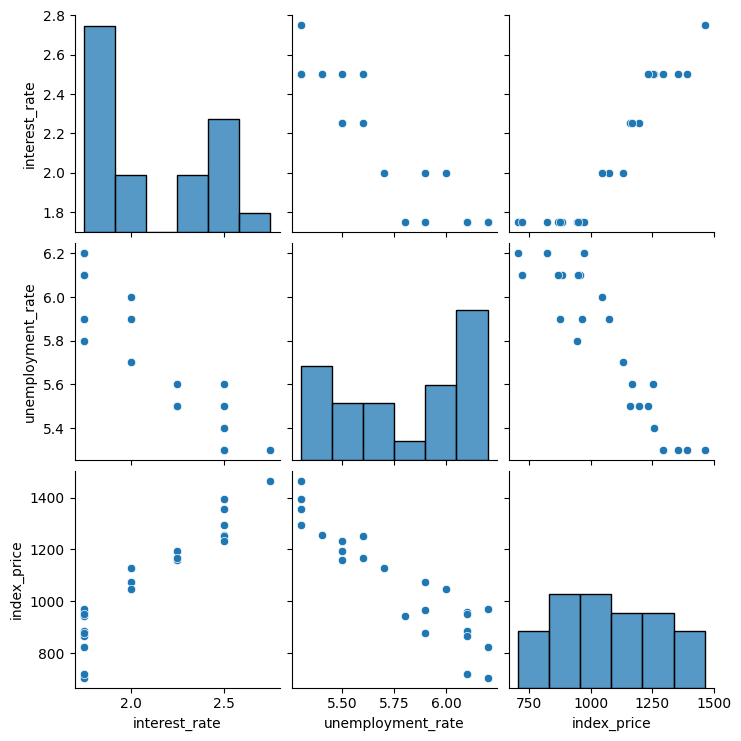

In [11]:
## Lets do some visualization
import seaborn as sns
sns.pairplot(df_index)

In [12]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

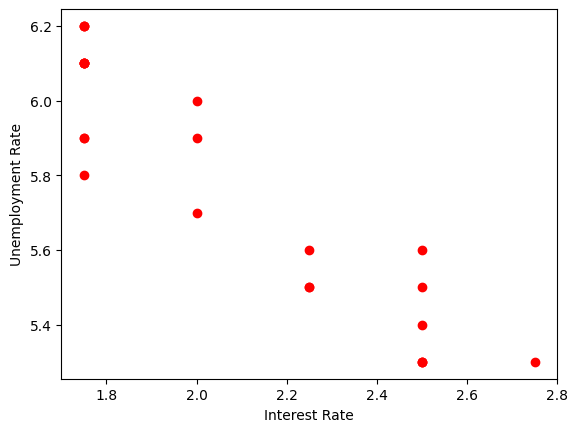

In [15]:
### Visualise the datapoints
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color = 'red')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')

In [16]:
## independant and dependant features
X = df_index.iloc[:,:-1]
y = df_index.iloc[:,-1]

In [17]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [18]:
y.head()

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256


In [19]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

<Axes: xlabel='interest_rate', ylabel='index_price'>

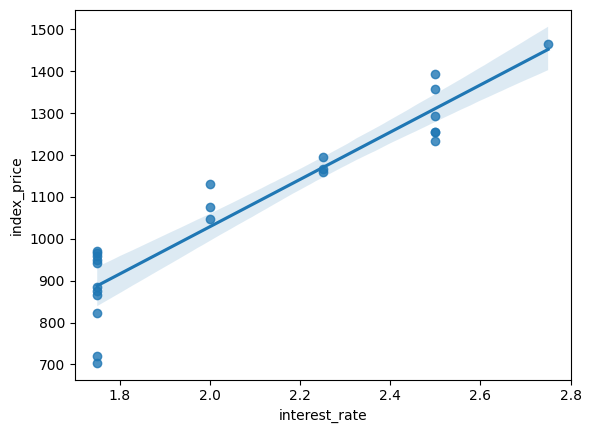

In [22]:
import seaborn as sns
sns.regplot(data=df_index, x='interest_rate', y='index_price')

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

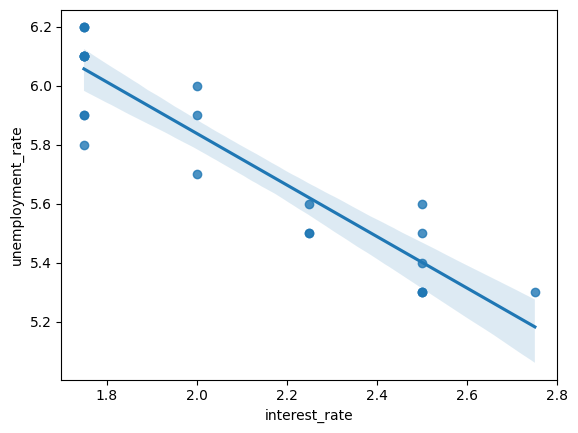

In [23]:
sns.regplot(data=df_index, x='interest_rate', y='unemployment_rate')

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

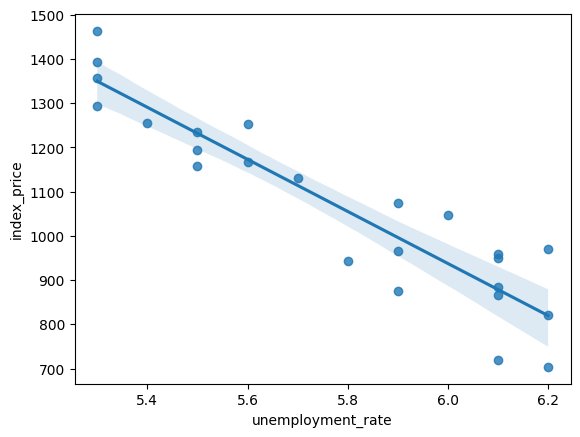

In [24]:
sns.regplot(data=df_index, x='unemployment_rate', y='index_price')

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [26]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [28]:
## Cross validation
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regressor, X_train, y_train, scoring = 'neg_mean_squared_error' ,cv=3)

In [29]:
validation_score

array([-8015.28437718,  -903.9026833 , -2706.63806009])

In [30]:
np.mean(validation_score)


np.float64(-3875.2750401898634)

In [32]:
## prediction
y_pred = regressor.predict(X_test)
print(y_pred)

[1022.11617625 1053.1882909   876.8775728   939.0218021   923.48574478
 1312.59338314]


In [34]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
print("MAE : ",mean_absolute_error(y_test,y_pred))
print("MSE : ",mean_squared_error(y_test,y_pred))
print("RMSE : ",np.sqrt(mean_squared_error(y_test,y_pred)))

MAE :  72.5739441988108
MSE :  7913.525322008846
RMSE :  88.95799751573125


In [36]:
##
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
score

0.8313408388278931

In [37]:
# display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7189013980464884

Text(0, 0.5, 'Predicted')

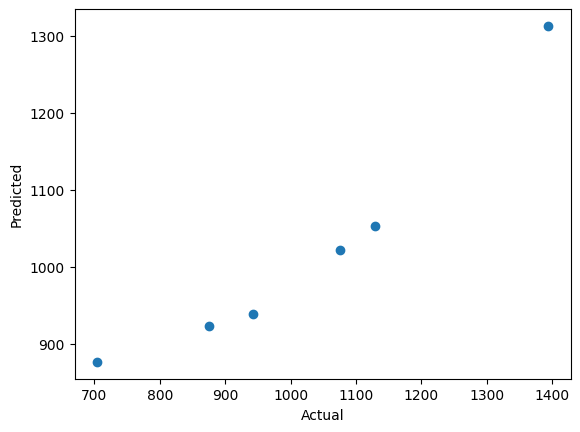

In [38]:
### asumptions
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

11     52.883824
10     76.811709
22   -172.877573
14      3.978198
20    -47.485745
1      81.406617
Name: index_price, dtype: float64


<Axes: xlabel='index_price', ylabel='Density'>

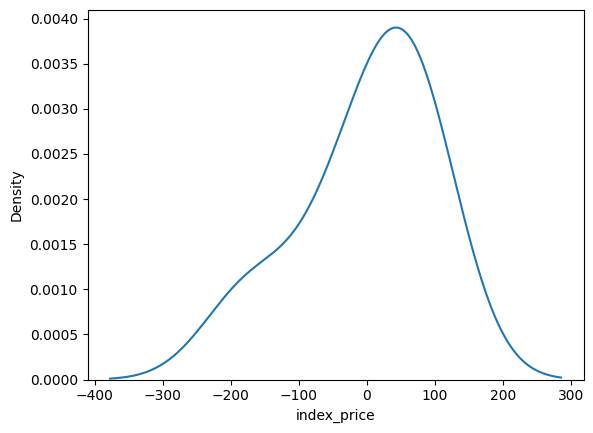

In [43]:
residuals = y_test - y_pred
print(residuals)
sns.kdeplot(residuals)

Text(0, 0.5, 'Residuals')

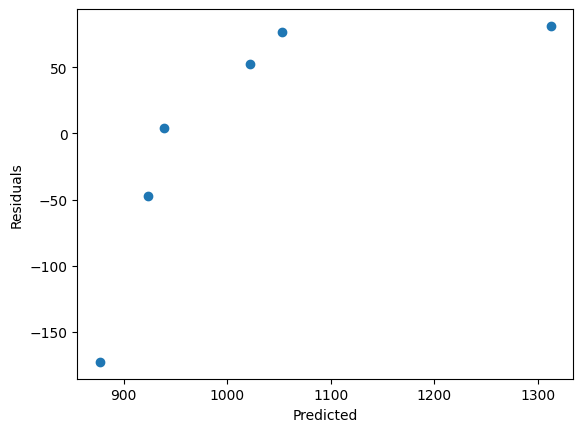

In [44]:
## scatter plot wrt predictions and residuals
plt.scatter(y_pred,residuals)
plt.xlabel('Predicted')
plt.ylabel('Residuals')

In [45]:
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()

In [46]:
prediction = model.predict(X_test)
print(prediction)

[ -64.55049042  -33.47837577 -209.78909387 -147.64486456 -163.18092189
  225.92671647]


In [47]:
print(regressor.coef_)

[140.34286806 -52.55792038]


In [48]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.030
Model:                            OLS   Adj. R-squared (uncentered):             -0.091
Method:                 Least Squares   F-statistic:                             0.2464
Date:                Thu, 11 Jun 2026   Prob (F-statistic):                       0.785
Time:                        14:22:06   Log-Likelihood:                         -151.40
No. Observations:                  18   AIC:                                      306.8
Df Residuals:                      16   BIC:                                      308.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------